### Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [2]:
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow_hub as hub

E:\software\miniconda3\envs\ml\lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


### Step 2: Load the Dataset

In [3]:
df = pd.read_csv('./data/spam.csv', encoding='latin-1')

In [4]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df.shape

(5572, 5)

### Step 3: Clean the dataset and encode labels

In [6]:
df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],axis=1)

In [7]:
df = df.rename(columns={'v1': 'label', 'v2': 'Text'})

In [8]:
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})

In [9]:
df.head()

,label,Text,label_enc
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


### Step 4: Split Data and convert to NumPy arrays

In [10]:
X_train, X_test, y_train, y_test = train_test_split(df['Text'], df['label_enc'], test_size=0.2, random_state=42)

In [11]:
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

### Step 5: Compute text Statistics for Vectorization

In [12]:
avg_words_len = round(sum([len(i.split()) for i in df['Text']]) / len(df['Text']))

In [13]:
total_words_length = len(set(" ".join(df['Text']).split()))

In [14]:
print(f"Data Loaded. Training samples: {len(X_train_np)}")
print(f"Average words per message: {avg_words_len}")
print(f"Approximate vocabulary size: {total_words_length}")

Data Loaded. Training samples: 4457
Average words per message: 16
Approximate vocabulary size: 15686


### Step 6: Helper functions for training and evaluation

In [15]:
def compile_and_fit(model, epochs=5):
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        X_train_np,
        y_train_np,
        epochs=epochs,
        validation_data=(X_test_np, y_test_np)
    )
    return history

In [16]:
def get_metrics(model, X, y):
    y_preds = np.round(model.predict(X))
    return {
        'accuracy': accuracy_score(y, y_preds),
        'precision': precision_score(y, y_preds),
        'recall': recall_score(y, y_preds),
        'f1-score': f1_score(y, y_preds)
    }

### Step 7: Create the TextVectorization layer

In [17]:
from tensorflow.keras.layers import TextVectorization

In [18]:
text_vec = TextVectorization(
    max_tokens=total_words_length,
    standardize='lower_and_strip_punctuation',
    output_mode='int',
    output_sequence_length=avg_words_len
)

In [19]:
text_vec.adapt(X_train_np)

### Step 8: Model 1 – Dense embedding model (build and train)

In [49]:
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_1 = keras.Model(input_layer, output_layer, name="Dense_Model")
history_1 = compile_and_fit(model_1)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9055 - loss: 0.2720 - val_accuracy: 0.9578 - val_loss: 0.1410
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9798 - loss: 0.0815 - val_accuracy: 0.9758 - val_loss: 0.0784
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9906 - loss: 0.0368 - val_accuracy: 0.9785 - val_loss: 0.0676
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9942 - loss: 0.0238 - val_accuracy: 0.9776 - val_loss: 0.0703
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9969 - loss: 0.0160 - val_accuracy: 0.9776 - val_loss: 0.0694


In [31]:
class DenseTextModel(tf.keras.Model):
    def __init__(self, vocab_size, embed_dim=128):
        super().__init__(name="Dense_Model")

        self.text_vec = text_vec

        self.embeding = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pool = layers.GlobalAveragePooling1D()
        self.fc1 = layers.Dense(32, activation='relu')
        self.fc2 = layers.Dense(1, activation='sigmoid')

    def call(self, inputs):
        """
        inputs: tf.string Tensor [batch_size, 1]
        """
        x = self.text_vec(inputs)
        x = self.embeding(x)
        x = self.pool(x)
        x = self.fc1(x)
        return self.fc2(x)

In [32]:
model_1 = DenseTextModel(total_words_length)

In [33]:
history_1 = compile_and_fit(model_1)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9073 - loss: 0.2619 - val_accuracy: 0.9596 - val_loss: 0.1408
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9785 - loss: 0.0828 - val_accuracy: 0.9749 - val_loss: 0.0774
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9904 - loss: 0.0377 - val_accuracy: 0.9758 - val_loss: 0.0672
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9962 - loss: 0.0206 - val_accuracy: 0.9767 - val_loss: 0.0660
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9971 - loss: 0.0144 - val_accuracy: 0.9794 - val_loss: 0.0640


### Step 9: Model 2 – Bidirectional LSTM model (build and train)

In [34]:
class BiLSTM(tf.keras.Model):
    def __init__(self, vocab_size, embed_dim=128):
        super().__init__(name="BiLSTM_Model")

        self.text_vec = text_vec

        self.embeding = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.bilstm1 = layers.Bidirectional(
            layers.LSTM(64, return_sequences=True)
        )
        self.bilstm2 = layers.Bidirectional(
            layers.LSTM(64)
        )

        self.flatten = layers.Flatten()
        self.dropout = layers.Dropout(0.1)
        self.fc1 = layers.Dense(32, activation='relu')
        self.fc2 = layers.Dense(1, activation='sigmoid')

    def call(self, inputs, training=False):
        x = self.text_vec(inputs)
        x = self.embeding(x)
        
        x = self.bilstm1(x)
        x = self.bilstm2(x)

        x = self.flatten(x)
        x = self.dropout(x, training = training)

        x = self.fc1(x)
        return self.fc2(x)

In [35]:
model_2 = BiLSTM(total_words_length)

In [36]:
history_2 = compile_and_fit(model_2)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9408 - loss: 0.1729 - val_accuracy: 0.9749 - val_loss: 0.0834
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9908 - loss: 0.0355 - val_accuracy: 0.9758 - val_loss: 0.0880
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9966 - loss: 0.0122 - val_accuracy: 0.9695 - val_loss: 0.1168
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9984 - loss: 0.0067 - val_accuracy: 0.9794 - val_loss: 0.0851
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9996 - loss: 0.0011 - val_accuracy: 0.9803 - val_loss: 0.1023


### Step 10: Model 3 – Transfer learning with Universal Sentence Encoder (build and train)

In [25]:
# TF Hub 的 Universal Sentence Encoder
use_layer = hub.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    trainable=False,
    input_shape=[],
    dtype=tf.string,
    name='USE'
)

In [26]:
class USETextModel(tf.keras.Model):
    def __init__(self):
        super().__init__(name='USE_Model')
        
        self.embeding = layers.Lambda(lambda x: use_layer(x), output_shape=(512,))

        # 分类头
        self.fc1 = layers.Dense(64, activation="relu")
        self.dropout = layers.Dropout(0.2)
        self.fc2 = layers.Dense(1, activation="sigmoid")

    def call(self, inputs, training=False):
        """
        inputs: tf.string tensor, shape [batch_size]
        """
        x = self.embeding(inputs)
        x = self.fc1(x)
        x = self.dropout(x, training=training)
        return self.fc2(x)

In [27]:
model_3 = USETextModel()

In [28]:
history_3 = compile_and_fit(model_3)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9228 - loss: 0.2918 - val_accuracy: 0.9740 - val_loss: 0.1094
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9796 - loss: 0.0785 - val_accuracy: 0.9821 - val_loss: 0.0691
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9836 - loss: 0.0568 - val_accuracy: 0.9830 - val_loss: 0.0590
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9874 - loss: 0.0455 - val_accuracy: 0.9857 - val_loss: 0.0548
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9892 - loss: 0.0399 - val_accuracy: 0.9848 - val_loss: 0.0540


### Step 11: Collect performance metrics for all models

In [37]:
results = {
    'Dense Embedding': get_metrics(model_1, X_test_np, y_test_np),
    'Bi-LSTM': get_metrics(model_2, X_test_np, y_test_np),
    'Transfer Learning (USE)': get_metrics(model_3, X_test_np, y_test_np)
}

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [41]:
results_df = pd.DataFrame(results).T

In [42]:
print("Performance Table:")
print(results_df)

Performance Table:
                         accuracy  precision    recall  f1-score
Dense Embedding          0.979372   0.963235  0.879195  0.919298
Bi-LSTM                  0.980269   0.970370  0.879195  0.922535
Transfer Learning (USE)  0.984753   0.964789  0.919463  0.941581


### Step 12: Visualize

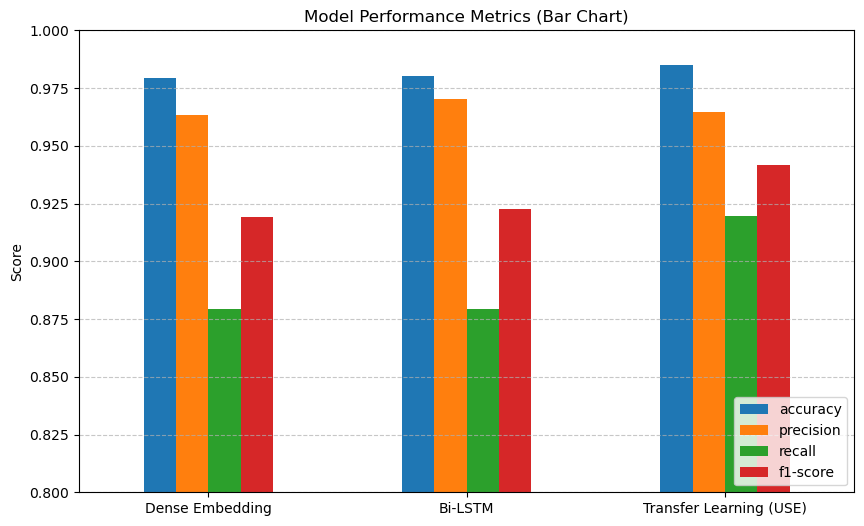

In [43]:
results_df.plot(kind='bar', figsize=(10, 6))
plt.title("Model Performance Metrics (Bar Chart)")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

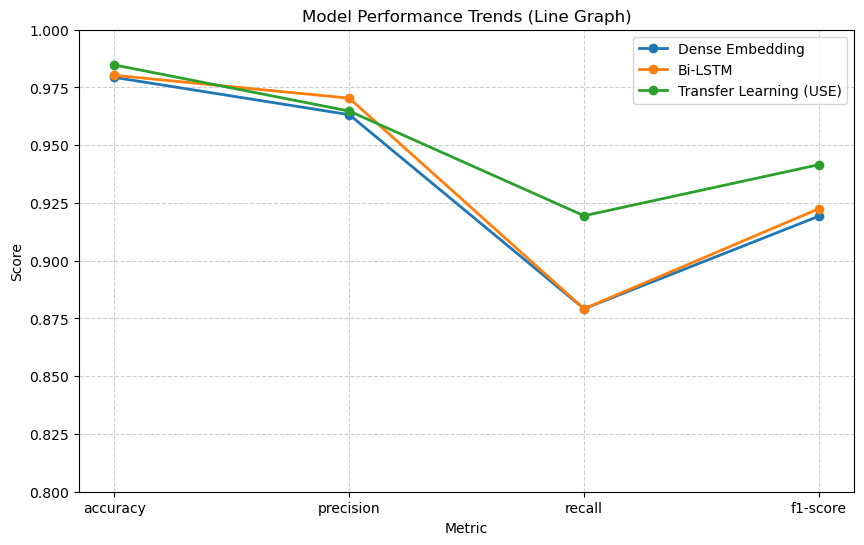

In [44]:
plt.figure(figsize=(10, 6))

for model_name in results_df.index:
    plt.plot(
        results_df.columns,
        results_df.loc[model_name],
        marker='o',
        label=model_name,
        linewidth=2
    )
plt.title("Model Performance Trends (Line Graph)")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0.8, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()